# 12: Sampling, selection, and verifier mistakes

[Course home](../README.md) · [Part III chapters](../chapters/README.md#part-iii-inference-time-reasoning-and-planning) · Topics **41–44**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/notebooks/12_sampling_and_selection.ipynb)

**Created by Shivam Bharadwaj**

Restart the kernel and run all cells. Defaults run on CPU using generated data and a transparent
categorical arithmetic policy. This is not an LLM benchmark. Colab clones published main when
necessary; local runs need the complete repository and its core requirements.

**Task contract:** left-to-right addition, three proposed intermediate sums, frozen error
probabilities, one unit per proposal, and a declared scorer-query cost. Independent final
evaluation is outside the inference allowance and cannot guide search. Count abstentions as
failures. The code is MIT; educational text and outputs use CC BY 4.0.

In [1]:
from pathlib import Path
import sys
import subprocess

# Local: open from the full checkout. Colab: clone the published course once.
roots = [Path.cwd(), Path.cwd().parent, Path('/content/rl-course')]
root = next((p for p in roots if (p / 'rl_course' / 'inference.py').exists()), None)
if root is None and 'google.colab' in sys.modules:
    root = Path('/content/rl-course')
    if not root.exists():
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(root)], check=True)
if root is None or not (root / 'rl_course' / 'inference.py').exists():
    raise RuntimeError('Use the complete updated repository. Colab uses published main; push Part III before opening its badge.')
sys.path.insert(0, str(root))

import math
import random
from statistics import mean
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course.inference import (Task, Trace, FrozenPolicy, METHODS, infer, evaluate,
                                 process_score, make_tasks, benchmark, distill)

plt.rcParams.update({'figure.figsize': (9, 4), 'figure.facecolor': '#f5f1e8',
                     'axes.facecolor': '#ffffff', 'text.color': '#292332',
                     'axes.labelcolor': '#292332', 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
COLORS = ['#292332', '#af824a', '#768165', '#87708c', '#95654f']
policy = FrozenPolicy()
tasks = make_tasks(100, seed=2026)
seeds = (7, 19, 41)
budgets = (6, 12, 24, 48)

def show_rows(rows):
    lines = ['| Method | Budget | Answer | Process | Oracle candidates | Used units | Completion |',
             '|---|---:|---:|---:|---:|---:|---:|']
    keys = list(dict.fromkeys((r['method'], r['budget']) for r in rows))
    for method, budget in keys:
        group = [r for r in rows if r['method'] == method and r['budget'] == budget]
        avg = lambda key: mean(r[key] for r in group)
        lines.append(f"| {method} | {budget} | {avg('answer_correct'):.1%} | {avg('process_valid'):.1%} | "
                     f"{avg('candidate_oracle_success'):.1%} | {avg('spent'):.1f} | {avg('completed'):.1%} |")
    display(Markdown('\n'.join(lines)))

def plot_rows(rows, metric='answer_correct', xmetric='budget'):
    fig, ax = plt.subplots()
    for color, method in zip(COLORS, dict.fromkeys(r['method'] for r in rows)):
        groups = [[r for r in rows if r['method'] == method and r['budget'] == b]
                  for b in sorted(set(r['budget'] for r in rows))]
        x = [mean(r[xmetric] for r in group) for group in groups]
        y = [mean(r[metric] for r in group) for group in groups]
        ax.plot(x, y, marker='o', label=method, color=color)
        # Show every generation-seed aggregate; these are not training seeds.
        for xx, group in zip(x, groups):
            ax.scatter([xx] * len(group), [r[metric] for r in group], color=color, alpha=.35, s=18)
    ax.set(xlabel='Budget cap' if xmetric == 'budget' else 'Mean work units actually used',
           ylabel=metric.replace('_', ' '), ylim=(-.03, 1.03))
    ax.legend(fontsize=8); fig.tight_layout(); plt.show()

print('Python', sys.version.split()[0], '| NumPy', np.__version__)
print('Frozen offsets (-1, 0, +1):', policy.probabilities)
print('100 unique tasks, 3 generation seeds; no model downloads or parameter updates during inference.')

Python 3.12.4 | NumPy 2.5.3
Frozen offsets (-1, 0, +1): (0.1, 0.4, 0.5)
100 unique tasks, 3 generation seeds; no model downloads or parameter updates during inference.


## 1. Calculate what the frozen policy can generate

Offsets are (-1,0,+1) with probabilities (0.1,0.4,0.5). Three valid steps occur with
probability 0.4³. A correct final answer also occurs when one -1 and one +1 cancel.
Derive its probability before running the cell. The exact process checker is strong
domain-specific supervision, not a learned reward model.

In [2]:
p_valid = .4**3
p_answer = p_valid + 6*.1*.4*.5
print(f'Exact one-attempt process validity: {p_valid:.3f}')
print(f'Exact one-attempt final correctness: {p_answer:.3f}')
task = Task((1, 1, 5))
print('Compensating-error trace:', evaluate(task, Trace((3, 7))))
rng = random.Random(2026)
draws = []
for _ in range(10000):
    trace = Trace()
    for _ in range(task.depth):
        trace = policy.propose(task, trace, rng)
    draws.append(evaluate(task, trace)['answer_correct'])
# This task has depth two, whose exact probability is .4² + 2*.1*.5.
observed = mean(draws)
assert abs(observed - (.4**2 + 2*.1*.5)) < .025
print('Two-step empirical correctness:', round(observed, 4))

Exact one-attempt process validity: 0.064
Exact one-attempt final correctness: 0.184
Compensating-error trace: {'completed': True, 'answer_correct': True, 'process_valid': False}
Two-step empirical correctness: 0.2673


## 2. Candidate-matched selection

Generate the same four complete traces for voting and best-of-N. Score queries add
cost to best-of-N, so these runs are candidate-matched rather than budget-matched.
Neither selector can inspect the final evaluator to choose its answer.

In [3]:
task = tasks[0]
voting = infer(task, policy, method='self_consistency', budget=12, seed=7)
ranked = infer(task, policy, method='best_of_n', budget=16, seed=7)
assert voting.candidates == ranked.candidates
for trace in voting.candidates:
    print(trace.values, 'process score:', process_score(task, trace), 'post-selection truth:', evaluate(task, trace))
print('Voting cost:', voting.ledger.spent, 'ranking cost:', ranked.ledger.spent)
print('Selected by voting:', voting.selected.values)
print('Selected by scorer:', ranked.selected.values)

(33, 59, 86) process score: 0.6666666666666666 post-selection truth: {'completed': True, 'answer_correct': False, 'process_valid': False}
(32, 59, 85) process score: 0.3333333333333333 post-selection truth: {'completed': True, 'answer_correct': True, 'process_valid': False}
(32, 59, 84) process score: 0.0 post-selection truth: {'completed': True, 'answer_correct': False, 'process_valid': False}
(33, 58, 83) process score: 0.3333333333333333 post-selection truth: {'completed': True, 'answer_correct': False, 'process_valid': False}
Voting cost: 12 ranking cost: 16
Selected by voting: (33, 59, 86)
Selected by scorer: (33, 59, 86)


## 3. Budget-matched comparison

Use the same tasks and budget caps. Scored methods can afford fewer full candidates.
Dots show individual generation-seed aggregates; lines show their means. Single
sampling spends three units regardless of a larger allowance.

| Method | Budget | Answer | Process | Oracle candidates | Used units | Completion |
|---|---:|---:|---:|---:|---:|---:|
| single | 6 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 6 | 22.7% | 8.3% | 37.0% | 6.0 | 100.0% |
| best_of_n | 6 | 22.7% | 8.3% | 22.7% | 4.0 | 100.0% |
| single | 12 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 12 | 18.3% | 5.7% | 56.7% | 12.0 | 100.0% |
| best_of_n | 12 | 23.3% | 17.3% | 49.0% | 12.0 | 100.0% |
| single | 24 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 24 | 12.3% | 5.3% | 81.3% | 24.0 | 100.0% |
| best_of_n | 24 | 34.7% | 31.7% | 71.7% | 24.0 | 100.0% |
| single | 48 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 48 | 9.0% | 3.0% | 96.3% | 48.0 | 100.0% |
| best_of_n | 48 | 53.3% | 52.7% | 92.0% | 48.0 | 100.0% |

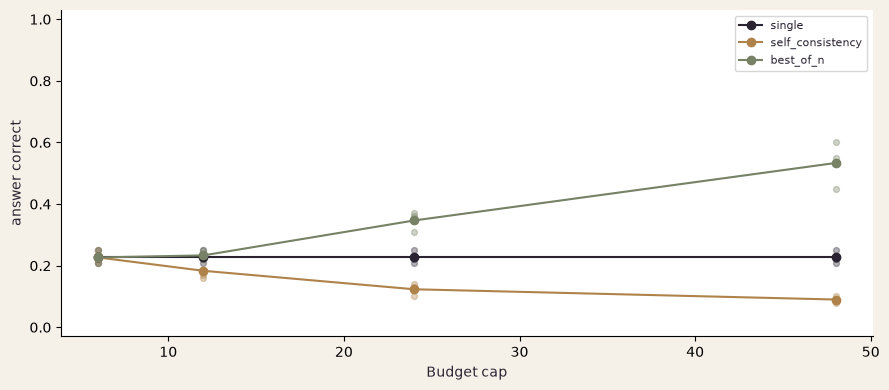

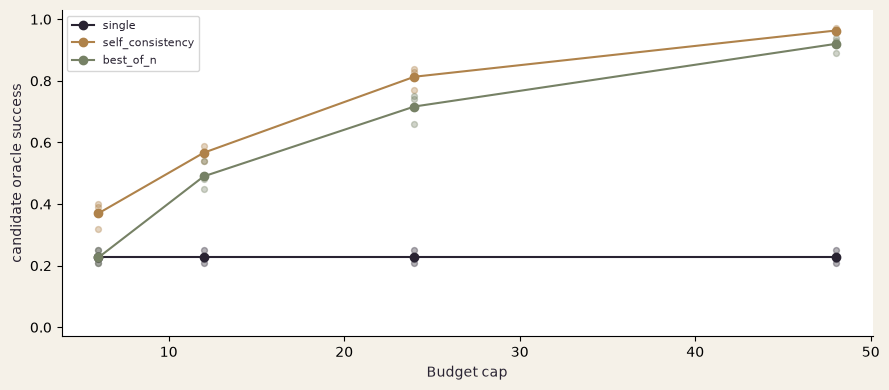

In [4]:
methods = ('single', 'self_consistency', 'best_of_n')
before = policy.probabilities
rows = benchmark(tasks, methods=methods, budgets=budgets, seeds=seeds, policy=policy)
assert policy.probabilities == before
show_rows(rows)
plot_rows(rows)
plot_rows(rows, metric='candidate_oracle_success')

## 4. A scorer that makes more samples harmful

Switch only the scoring signal. The misleading scorer rewards +1 arithmetic errors.
The candidate stream remains unchanged for best-of-N at the same seed and budget.
This is a controlled objective-mismatch experiment, not a claim that all reward models
behave this way.

| Method | Budget | Answer | Process | Oracle candidates | Used units | Completion |
|---|---:|---:|---:|---:|---:|---:|
| best_of_n | 6 | 22.7% | 8.3% | 22.7% | 4.0 | 100.0% |
| best_of_n | 12 | 6.0% | 0.3% | 49.0% | 12.0 | 100.0% |
| best_of_n | 24 | 0.7% | 0.0% | 71.7% | 24.0 | 100.0% |
| best_of_n | 48 | 0.0% | 0.0% | 92.0% | 48.0 | 100.0% |

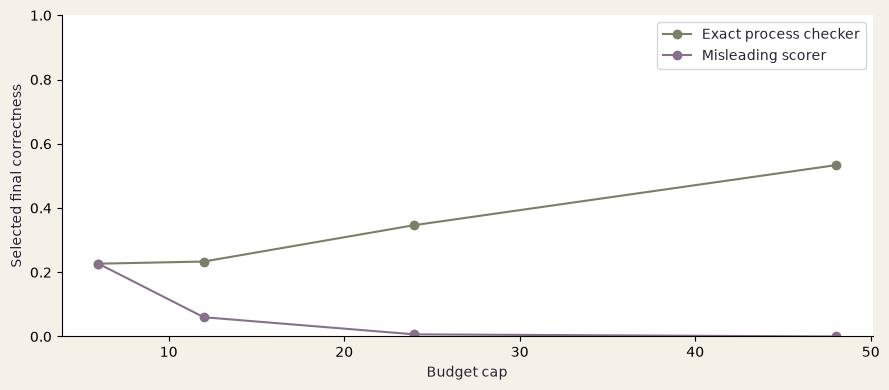

Candidate-stream invariance passed for the scorer ablation.


In [5]:
bad = benchmark(tasks, methods=('best_of_n',), budgets=budgets, seeds=seeds, scorer='misleading')
show_rows(bad)
fig, ax = plt.subplots()
for source, label, color in [(rows, 'Exact process checker', '#768165'), (bad, 'Misleading scorer', '#87708c')]:
    ys = [mean(r['answer_correct'] for r in source if r['budget']==b and r['method']=='best_of_n') for b in budgets]
    ax.plot(budgets, ys, marker='o', label=label, color=color)
ax.set(xlabel='Budget cap', ylabel='Selected final correctness', ylim=(0,1)); ax.legend(); fig.tight_layout(); plt.show()
for b in budgets:
    good_run = infer(tasks[0], method='best_of_n', budget=b, seed=19)
    bad_run = infer(tasks[0], method='best_of_n', budget=b, seed=19, scorer='misleading')
    assert good_run.candidates == bad_run.candidates
print('Candidate-stream invariance passed for the scorer ablation.')

## 5. Exercises

1. Calculate oracle success for p=0.184 and N=12, then compare it with measured selected success.
2. Use error probabilities (0.1,0.8,0.1). Does the self-consistency failure persist?
3. Keep a candidate pool fixed and implement highest-sequence-likelihood selection.
4. Explain why final correctness can exceed valid-process rate.

<details><summary>Answers and investigation guidance</summary>

1. `1-(1-.184)**12`, approximately 0.913. This is an independent-sample oracle opportunity,
   not a guaranteed selected accuracy.
2. Rerun the fixed protocol; the constructed dominant wrong-answer distribution has changed.
   Report the result rather than assuming the original ranking survives.
3. Rank the stored `log_probability` values without using evaluator truth. Record ties.
4. Opposite local errors can cancel in the final sum while invalidating the intermediate path.

</details>

Read [Self-Consistency](https://arxiv.org/abs/2203.11171) and
[Chapter 43](../chapters/43-sampling-and-candidate-selection/README.md).